## Install Dependencies

In [ ]:
!pip install opencv-python
!pip install tensorflow
!pip install kagglehub

## Importing Libraries

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## Importing Dataset

In [3]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


## Loading Model

In [4]:
# Load trained CNN model
model = tf.keras.models.load_model('/trained_model.keras')

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,528,288 (89.75 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,685,526 (59.84 MB)

In [6]:
for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

conv2d Conv2D
conv2d_1 Conv2D
max_pooling2d MaxPooling2D
conv2d_2 Conv2D
conv2d_3 Conv2D
max_pooling2d_1 MaxPooling2D
conv2d_4 Conv2D
conv2d_5 Conv2D
max_pooling2d_2 MaxPooling2D
conv2d_6 Conv2D
conv2d_7 Conv2D
max_pooling2d_3 MaxPooling2D
conv2d_8 Conv2D
conv2d_9 Conv2D
max_pooling2d_4 MaxPooling2D
dropout Dropout
flatten Flatten
dense Dense
dropout_1 Dropout
dense_1 Dense


In [7]:
old_model = model

inputs = tf.keras.Input(shape=(128, 128, 3))

x = inputs
for layer in old_model.layers:
    x = layer(x)

model = tf.keras.Model(inputs=inputs, outputs=x)

In [31]:
model.input, model.output

(<KerasTensor shape=(None, 128, 128, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_210>,
 <KerasTensor shape=(None, 38), dtype=float32, sparse=False, ragged=False, name=keras_tensor_230>)

## Visualizing Single Image of Test set

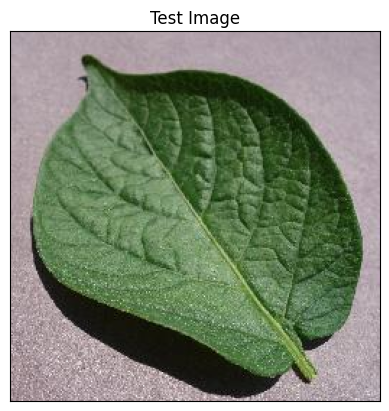

In [99]:
import cv2
image_path = "/kaggle/input/new-plant-diseases-dataset/test/test/PotatoHealthy1.JPG"

# Reading Image
img = cv2.imread(image_path) # BGR Format
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # RGB Format

# Resizing Image
# img = cv2.resize(img, (256, 256))

# Displaying Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

In [100]:
image = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
print(input_arr.shape)

(1, 128, 128, 3)


## Testing Model

In [101]:
predictions = model.predict(input_arr)
predictions, predictions.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


(array([[1.9935488e-08, 1.9726875e-07, 1.8233062e-10, 9.9644137e-07,
         1.6145567e-07, 1.1112561e-09, 3.0792665e-03, 1.4171560e-11,
         8.4177020e-11, 1.2893512e-11, 2.5013443e-11, 2.1347286e-10,
         3.6988085e-10, 8.4394373e-11, 4.6303017e-10, 1.3413999e-09,
         2.5651606e-10, 2.1492691e-10, 6.1279883e-07, 3.7347956e-05,
         8.4824370e-09, 2.2316949e-07, 9.9687874e-01, 9.2123464e-08,
         2.2940858e-06, 8.8655272e-12, 6.3138184e-12, 2.7289150e-08,
         2.2693403e-10, 2.7359194e-08, 8.5167740e-09, 9.7077368e-10,
         4.1760941e-08, 1.7642562e-09, 3.7916927e-09, 2.0369829e-11,
         1.2662428e-10, 7.5366900e-11]], dtype=float32),
 (1, 38))

In [102]:
result_idx = np.argmax(predictions[0])
result_idx

np.int64(22)

In [62]:
# Copied the class_names from the validation_set
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [103]:
print("Predicted class index:", result_idx)
print("Predicted disease:", class_name[result_idx])

Predicted class index: 22
Predicted disease: Potato___healthy


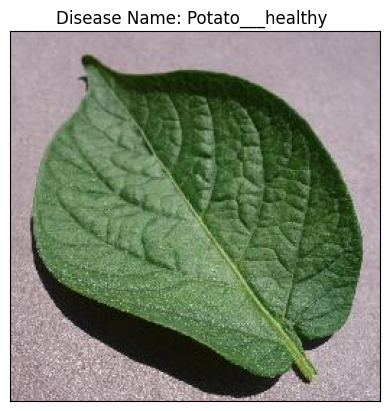

In [104]:
# Displaying Result of disease prediction
model_prediction = class_name[result_idx]
# Displaying Image
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction} ")
plt.xticks([])
plt.yticks([])
plt.show()

## Add Grad-CAM function
Grad-CAM (Gradient-weighted Class Activation Mapping) is an explainable AI technique used to visualize which regions of an image contribute the most toward a CNN model’s prediction.

In this project, Grad-CAM helps interpret how the plant disease classification model identifies infected leaf regions by highlighting the areas that strongly influence the predicted disease class.

In [94]:
"""
  Compute Grad-CAM activation maps by calculating gradients of the predicted class with respect to the convolution feature maps.
"""
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    img_tensor = tf.convert_to_tensor(img_array)

    with tf.GradientTape() as tape:
        x = img_tensor
        conv_output = None

        for layer in model.layers:

            # Skip InputLayer
            if isinstance(layer, tf.keras.layers.InputLayer):
                continue

            x = layer(x, training=False)

            if layer.name == last_conv_layer_name:
                conv_output = x
                tape.watch(conv_output)

        predictions = x

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)

    if grads is None:
        raise ValueError("Gradients are None. Try using conv2d_8 instead of conv2d_9.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if max_val != 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()

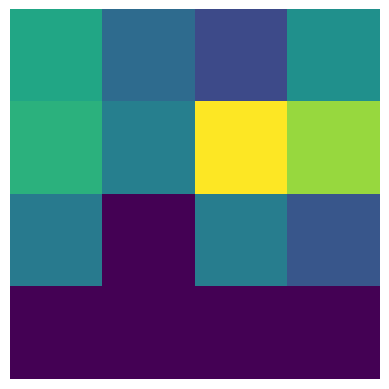

In [105]:
last_conv_layer_name = "conv2d_9"

"""
Generate a heatmap representing the regions of the leaf image most influential in the disease prediction process.
"""
heatmap = make_gradcam_heatmap(
    input_arr,
    model,
    last_conv_layer_name,
    pred_index=result_idx
)

# Display the raw Grad-CAM activation map to observe spatial attention regions learned by the CNN model.
plt.imshow(heatmap)
plt.axis("off")
plt.show()

In [106]:
print(input_arr.shape)
print(input_arr.min(), input_arr.max())

(1, 128, 128, 3)
0.0 255.0


### Overlay Heatmap on Original Leaf Image

In [97]:
def display_gradcam(original_img, heatmap, alpha=0.4):
    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    superimposed_img = heatmap_color * alpha + original_img
    superimposed_img = np.uint8(superimposed_img)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(original_img.astype("uint8"))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: {class_name[result_idx]}")
    plt.axis("off")

    safe_name = class_name[result_idx].replace("/", "_").replace(" ", "_")

    plt.savefig(
    f"gradcam_{safe_name}.png",
    bbox_inches='tight',
    dpi=300
)

    plt.show()

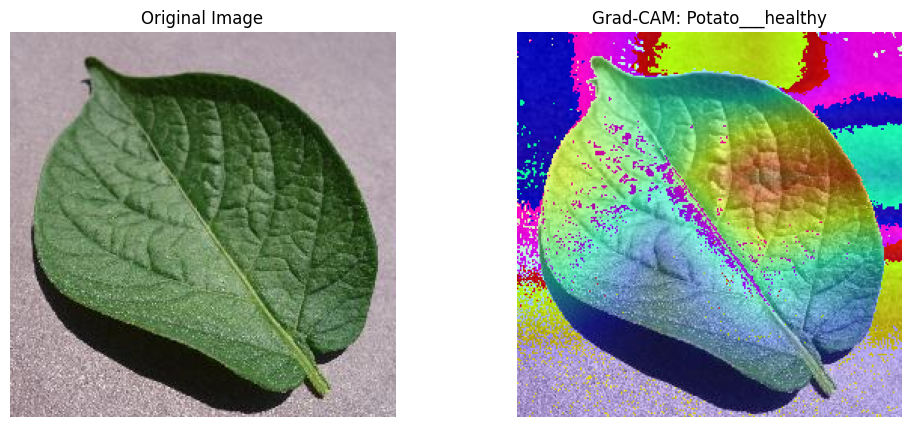

In [107]:
display_gradcam(img, heatmap)

The Grad-CAM visualization indicates that the CNN model focuses primarily on lesion and discoloration regions associated with plant disease symptoms, demonstrating that the model has learned biologically relevant visual patterns rather than relying on background artifacts.

### List Grad-CAM Files

In [108]:
import glob

# List all files matching the pattern 'gradcam_*.png' in the current directory
gradcam_files = glob.glob('gradcam_*.png')

if gradcam_files:
    print('Found Grad-CAM files:')
    for file_name in gradcam_files:
        print(file_name)
else:
    print('No Grad-CAM files found in the current directory.')

Found Grad-CAM files:
gradcam_Potato___Early_blight.png
gradcam_Tomato___Tomato_Yellow_Leaf_Curl_Virus.png
gradcam_Corn_(maize)___Common_rust_.png
gradcam_Potato___healthy.png
gradcam_Apple___Cedar_apple_rust.png


### Image Location

In [110]:
!ls /content/gradcam_*.png

 /content/gradcam_Apple___Cedar_apple_rust.png
'/content/gradcam_Corn_(maize)___Common_rust_.png'
 /content/gradcam_Potato___Early_blight.png
 /content/gradcam_Potato___healthy.png
 /content/gradcam_Tomato___Tomato_Yellow_Leaf_Curl_Virus.png


## Testing on Real World Images (from Google Images)

This section evaluates the trained CNN model on real-world plant images collected from external sources, including healthy plants, known diseases, and out-of-distribution plant species.

The objective is to analyze:
- generalization capability,
- robustness to natural backgrounds,
- explainability using Grad-CAM,
- and model behavior on unseen plant species.

In [111]:
import os

os.makedirs("outputs/healthy", exist_ok=True)
os.makedirs("outputs/known_diseases", exist_ok=True)
os.makedirs("outputs/unknown_plants", exist_ok=True)

In [112]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(img, (128, 128))

    input_arr = np.expand_dims(resized, axis=0)
    input_arr = input_arr.astype(np.float32)

    predictions = model.predict(input_arr, verbose=0)

    result_idx = np.argmax(predictions[0])

    confidence = float(np.max(predictions[0]))

    predicted_class = class_name[result_idx]

    return img, input_arr, predicted_class, confidence, result_idx

In [115]:
def process_folder(folder_path, output_folder):
    image_files = os.listdir(folder_path)

    for image_name in image_files:

        image_path = os.path.join(folder_path, image_name)

        try:
            img, input_arr, predicted_class, confidence, result_idx = predict_image(image_path)

            heatmap = make_gradcam_heatmap(
                input_arr,
                model,
                "conv2d_9",
                pred_index=result_idx
            )

            save_gradcam(
                img,
                heatmap,
                predicted_class,
                confidence,
                image_name,
                output_folder
            )

            print(f"{image_name}")
            print(f"Prediction: {predicted_class}")
            print(f"Confidence: {confidence:.4f}")
            print("-" * 50)

        except Exception as e:
            print(f"Error processing {image_name}: {e}")

In [116]:
def save_gradcam(original_img,
                 heatmap,
                 predicted_class,
                 confidence,
                 image_name,
                 output_folder):

    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    superimposed_img = heatmap_color * 0.4 + original_img
    superimposed_img = np.uint8(superimposed_img)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(superimposed_img)
    plt.title(f"{predicted_class}\nConfidence: {confidence:.2f}")
    plt.axis("off")

    save_path = os.path.join(output_folder, image_name)

    plt.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.close()

In [114]:
import zipfile

with zipfile.ZipFile("/real_world_test.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [117]:
process_folder(
    "/content/real_world_test/healthy",
    "/content/outputs/healthy"
)

process_folder(
    "/content/real_world_test/known_diseases",
    "/content/outputs/known_diseases"
)

process_folder(
    "/content/real_world_test/unknown_plants",
    "/content/outputs/unknown_plants"
)

Apple_leaf_close_up.webp
Prediction: Tomato___Late_blight
Confidence: 0.9446
--------------------------------------------------
Potato_health_leaf.jpeg
Prediction: Squash___Powdery_mildew
Confidence: 0.7151
--------------------------------------------------
Tomato_leaf_healthy.jpg
Prediction: Corn_(maize)___healthy
Confidence: 1.0000
--------------------------------------------------
Corn_leaf_healthy.webp
Prediction: Tomato___Late_blight
Confidence: 0.9000
--------------------------------------------------
Grape_leaf_outdoor.webp
Prediction: Strawberry___Leaf_scorch
Confidence: 0.7583
--------------------------------------------------
Corn_common_rust_leaf_close_up.jpg
Prediction: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Confidence: 0.3784
--------------------------------------------------
Tomato_leaf_with_spider_mite_damage.jpeg
Prediction: Tomato___Late_blight
Confidence: 0.9956
--------------------------------------------------
Tomato_leaf_septoria_leaf_spot.jpeg
Predicti

### Real-World Testing Interpretation

Although the CNN achieved high validation accuracy on the curated dataset, its performance dropped significantly on real-world images collected from external sources. Several healthy and diseased leaves were misclassified with high confidence, such as healthy tomato being predicted as healthy corn and apple scab being predicted as squash powdery mildew.

This suggests that the model learned dataset-specific visual patterns from the PlantVillage-style images and struggled to generalize to natural backgrounds, varied lighting, different camera angles, and field-like conditions.

The model also produced confident predictions for out-of-distribution plant species such as mango, banana, rose, and melon. Since the classifier does not include an “unknown” class, it is forced to assign every image to one of the 38 known classes, even when the input does not belong to the training distribution.

These results highlight the need for real-world data augmentation, uncertainty estimation, unknown-class rejection, and field-image fine-tuning before deploying the model in practical agricultural settings.

In [118]:
!zip -r outputs.zip outputs

  adding: outputs/ (stored 0%)
  adding: outputs/healthy/ (stored 0%)
  adding: outputs/healthy/Apple_leaf_close_up.webp (deflated 0%)
  adding: outputs/healthy/Potato_health_leaf.jpeg (deflated 2%)
  adding: outputs/healthy/Tomato_leaf_healthy.jpg (deflated 4%)
  adding: outputs/healthy/Corn_leaf_healthy.webp (deflated 1%)
  adding: outputs/healthy/Grape_leaf_outdoor.webp (deflated 0%)
  adding: outputs/known_diseases/ (stored 0%)
  adding: outputs/known_diseases/Corn_common_rust_leaf_close_up.jpg (deflated 5%)
  adding: outputs/known_diseases/Tomato_leaf_with_spider_mite_damage.jpeg (deflated 5%)
  adding: outputs/known_diseases/Tomato_leaf_septoria_leaf_spot.jpeg (deflated 4%)
  adding: outputs/known_diseases/Tomato_leaf_late_blight.jpeg (deflated 2%)
  adding: outputs/known_diseases/Apple_scab_leaf_disease.jpg (deflated 5%)
  adding: outputs/known_diseases/Tomato_leaf_early_blight.jpeg (deflated 3%)
  adding: outputs/known_diseases/Potato_early_blight.jpg (deflated 5%)
  adding: ou

In [119]:
from google.colab import files

files.download("outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>